In [1]:
from f1_replay import Manager

# Initialize loader
manager=Manager(cache_dir="race_data", timezone='Europe/Oslo')
manager.load_weekend(2024, 21, sessions=["race"], force_update=True)
#manager.load_race(force_update=True)
manager

✓ FastF1 cache: race_data/.fastf1_cache
✓ DataLoader initialized: race_data

📡 Building seasons catalog from FastF1...
→ Building F1 seasons catalog...
  ✓ 2021: 23 rounds
  ✓ 2022: 24 rounds
  ✓ 2023: 23 rounds
  ✓ 2024: 25 rounds
  ✓ 2025: 25 rounds
  ✓ 2026: 26 rounds
✓ Cached seasons to race_data/seasons.pkl


📡 Building weekend data from FastF1...
→ Loading weekend 2024 Round 21...
  → Building circuit with track geometry...
  ✓ Rotation: 258.0° (FastF1)
  → Loading race session for track extraction...
  → Extracting track from race winner: VER
  → Building light telemetry for VER...
    ✓ Track from VER lap 67 (80.3s): 316 points, 4208m
    ✓ Pit lane from VER: 271 points, 1319m (entry=3895m, exit=989m)
    ✓ Marshal sectors: 16
    ✓ Corners: 15
  ✓ Weekend complete: São Paulo Grand Prix
✓ Cached weekend to race_data/2024/21_São_Paulo/Weekend.pkl


📡 Building session data from FastF1...
→ Loading session 2024 R21 R...
  → DNF drivers from results: ALB, COL, HUL, SAI, STR
  → Bui

Manager(
  seasons[2021, 2022, 2023, 2024, 2025, 2026],
  weekend=RaceWeekend(2024 R21: São Paulo Grand Prix, date="1-3 Nov", sessions=[FP1, SQ, S, Q, R], race=loaded)
)

In [ ]:
manager.race(port=5001, debug=False)
print("Start warm up: ", manager.weekend.race.warm_up_offset)
print("Race start up: ", manager.weekend.race.lights_out_offset)


✓ Using loaded race: São Paulo Grand Prix (2024)

 Starting Flask app on http://0.0.0.0:5001...
 * Serving Flask app 'f1_replay.api.app'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5001
 * Running on http://192.168.68.62:5001
Press CTRL+C to quit
127.0.0.1 - - [14/Jan/2026 23:12:30] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [14/Jan/2026 23:12:30] "GET /api/seasons HTTP/1.1" 200 -
127.0.0.1 - - [14/Jan/2026 23:12:30] "GET /api/weekend/2024/21 HTTP/1.1" 200 -
127.0.0.1 - - [14/Jan/2026 23:12:30] "GET /api/session/2024/21/R?telemetry_fields=session_time,lap_number,x,y,track_distance,race_distance,position,interval,status,compound,tyre_life,speed HTTP/1.1" 200 -


In [3]:
manager.season_schedule(2025)


  F1 SEASON 2025
  ══════════════════════════════════════════════════════════════════════════════════
  T01  26 - 28 Feb  Pre-Season Testing  Sakhir             FP1, FP2, FP3
  R01  14 - 16 Mar  Australian GP       Melbourne          FP1, FP2, FP3, Q, R
  R02  21 - 23 Mar  Chinese GP          Shanghai           FP1, SQ, S, Q, R
  R03   4 -  6 Apr  Japanese GP         Suzuka             FP1, FP2, FP3, Q, R
  R04  11 - 13 Apr  Bahrain GP          Sakhir             FP1, FP2, FP3, Q, R
  R05  18 - 20 Apr  Saudi Arabian GP    Jeddah             FP1, FP2, FP3, Q, R
  R06   2 -  4 May  Miami GP            Miami Gardens      FP1, SQ, S, Q, R
  R07  16 - 18 May  Emilia Romagna GP   Imola              FP1, FP2, FP3, Q, R
  R08  23 - 25 May  Monaco GP           Monaco             FP1, FP2, FP3, Q, R
  R09  30 -  1 Jun  Spanish GP          Barcelona          FP1, FP2, FP3, Q, R
  R10  13 - 15 Jun  Canadian GP         Montréal           FP1, FP2, FP3, Q, R
  R11  27 - 29 Jun  Austrian GP         

In [2]:
#manager.weekend.race.track_status.to_pandas()

In [2]:
manager.weekend.race.get_telemetry_every_minute("TSU", interval=0.5).to_pandas()

,session_time,status,x,y,z,rpm,speed,n_gear,throttle,brake,drs,lap_number,compound,tyre_life,vx,vy,track_distance,race_distance,position,interval
0,2.343,PreSession,3267.0,454.0,0.0,0.0,0.0,0,0.0,False,0,-1,HARD,1.0,0.000000e+00,-0.000000e+00,220.498184,-11619.071289,18,0.0
1,35.889,PreSession,0.0,0.0,0.0,0.0,0.0,0,0.0,False,0,-1,HARD,1.0,0.000000e+00,-0.000000e+00,5861.263672,-5978.305664,1,0.0
2,62.289,PreSession,0.0,0.0,0.0,0.0,0.0,0,0.0,False,0,-1,HARD,1.0,0.000000e+00,-0.000000e+00,5861.263672,-5978.305664,1,0.0
3,92.429,PreSession,0.0,0.0,0.0,0.0,0.0,0,0.0,False,0,-1,HARD,1.0,0.000000e+00,-0.000000e+00,5861.263672,-5978.305664,1,0.0
4,122.309,PreSession,0.0,0.0,0.0,0.0,0.0,0,0.0,False,0,-1,HARD,1.0,0.000000e+00,-0.000000e+00,5861.263672,-5978.305664,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308,9242.307,Finished,-13726.0,-11128.0,-236.0,6057.0,68.0,2,4.0,False,0,52,MEDIUM,19.0,1.751908e+02,4.568415e+01,4041.946289,307828.812500,6,0.0
309,9272.367,Finished,-8081.0,-4406.0,-239.0,8443.0,118.0,3,16.0,False,0,52,MEDIUM,19.0,2.614143e+02,1.796707e+02,4944.256348,307828.812500,6,0.0
310,9302.767,Finished,32.0,-893.0,-244.0,3627.0,51.0,0,0.0,True,0,52,MEDIUM,19.0,1.400350e+02,4.061881e+01,5828.971680,307828.812500,6,0.0
311,9332.266,Finished,602.0,-659.0,-244.0,0.0,0.0,0,0.0,False,0,52,MEDIUM,19.0,3.550710e-12,1.491709e-12,5890.685059,307828.812500,6,0.0


In [3]:
import pandas as pd
pd.set_option('display.max_rows', 400)
manager.weekend.race.get_telemetry_every_minute("GAS", interval=.5).to_pandas()

,session_time,status,x,y,z,rpm,speed,n_gear,throttle,brake,drs,lap_number,compound,tyre_life,vx,vy,track_distance,race_distance,position,interval
0,2.343,PreSession,3267.0,454.0,0.0,0.0,0.0,0,0.0,False,0,-1,HARD,1.0,0.000000e+00,0.000000e+00,220.498184,-11619.071289,18,0.000000
1,35.889,PreSession,0.0,0.0,0.0,0.0,0.0,0,0.0,False,0,-1,HARD,1.0,0.000000e+00,0.000000e+00,5861.263672,-5978.305664,1,0.000000
2,62.289,PreSession,0.0,0.0,0.0,0.0,0.0,0,0.0,False,0,-1,HARD,1.0,0.000000e+00,0.000000e+00,5861.263672,-5978.305664,1,0.000000
3,92.429,PreSession,0.0,0.0,0.0,0.0,0.0,0,0.0,False,0,-1,HARD,1.0,0.000000e+00,0.000000e+00,5861.263672,-5978.305664,1,0.000000
4,122.309,PreSession,0.0,0.0,0.0,0.0,0.0,0,0.0,False,0,-1,HARD,1.0,0.000000e+00,0.000000e+00,5861.263672,-5978.305664,1,0.000000
5,152.229,PreSession,0.0,0.0,0.0,0.0,0.0,0,0.0,False,0,-1,HARD,1.0,0.000000e+00,0.000000e+00,5861.263672,-5978.305664,1,0.000000
6,182.509,PreSession,0.0,0.0,0.0,0.0,0.0,0,0.0,False,0,-1,HARD,1.0,0.000000e+00,0.000000e+00,5861.263672,-5978.305664,1,0.000000
7,212.149,PreSession,0.0,0.0,0.0,0.0,0.0,0,0.0,False,0,-1,HARD,1.0,0.000000e+00,0.000000e+00,5861.263672,-5978.305664,1,0.000000
8,242.388,PreSession,0.0,0.0,0.0,0.0,0.0,0,0.0,False,0,-1,HARD,1.0,0.000000e+00,0.000000e+00,5861.263672,-5978.305664,1,0.000000
9,272.249,PreSession,0.0,0.0,0.0,0.0,0.0,0,0.0,False,0,-1,HARD,1.0,0.000000e+00,0.000000e+00,5861.263672,-5978.305664,1,0.000000


In [3]:
manager.weekend.race.get_order_at_time(9092.348)

[(1, 'VER', 307778.21875),
 (2, 'RUS', 307828.8125),
 (3, 'SAI', 307828.8125),
 (4, 'ANT', 307828.8125),
 (5, 'LAW', 307818.71875),
 (6, 'TSU', 307828.8125),
 (7, 'NOR', 307826.4375),
 (8, 'HAM', 307828.8125),
 (9, 'LEC', 307828.8125),
 (10, 'GAS', 301899.6875),
 (11, 'COL', 301909.03125),
 (12, 'HAD', 307767.15625),
 (13, 'ALB', 305919.53125),
 (14, 'BOR', 305659.84375),
 (15, 'BEA', 305627.15625),
 (16, 'OCO', 305064.09375),
 (17, 'ALO', 304962.40625),
 (18, 'HUL', 304855.90625),
 (19, 'STR', 304383.5),
 (20, 'PIA', 7983.75390625)]

In [6]:
manager.weekend.race.get_telemetry_every_minute("NOR", interval=10).to_pandas()

,session_time,status,x,y,z,rpm,speed,n_gear,throttle,brake,drs,lap_number,compound,tyre_life,vx,vy,track_distance,race_distance,position,interval
0,2.343,PreSession,3268.0,455.0,0.0,0.0,0.0,0,0.0,False,0,-1,MEDIUM,1.0,0.000000e+00,-0.000000e+00,220.628174,220.628174,17,-3221.345996
1,602.289,PreSession,0.0,0.0,0.0,1385.0,0.0,0,104.0,True,1,-1,MEDIUM,1.0,0.000000e+00,-0.000000e+00,5861.263672,5861.263672,1,0.000000
2,1202.309,PreSession,2514.0,140.0,-244.0,4282.0,37.0,1,0.0,False,1,-1,MEDIUM,1.0,-9.944373e+01,-1.445483e+02,139.234741,139.234741,19,-2049.571674
3,1802.290,PreSession,821.0,-693.0,-246.0,0.0,0.0,0,0.0,False,0,-1,MEDIUM,1.0,-2.539431e-01,-1.401298e-45,5909.569336,5909.569336,6,-1575.385147
4,2402.250,PreSession,820.0,-694.0,-246.0,0.0,0.0,0,0.0,False,0,-1,MEDIUM,1.0,1.233143e-43,5.885454e-44,5909.438477,5909.438477,5,-1020.473539
5,3002.310,PreSession,820.0,-694.0,-246.0,0.0,0.0,0,0.0,False,1,-1,MEDIUM,1.0,0.000000e+00,0.000000e+00,5909.438477,5909.438477,7,-424.951370
6,3601.970,Racing,2844.0,2900.0,-236.0,10282.0,205.0,5,11.0,True,1,3,MEDIUM,2.0,-1.931738e+02,4.107122e+02,515.160706,12354.730469,8,1.987454
7,4202.270,Racing,-2117.0,-1839.0,-236.0,11614.0,329.0,8,100.0,False,1,6,MEDIUM,5.0,8.517378e+02,3.497572e+02,5594.157715,35193.082031,9,0.040531
8,4802.391,Racing,-12509.0,-3991.0,-145.0,6871.0,90.0,3,43.0,False,0,12,MEDIUM,11.0,-1.418901e+02,2.160752e+02,2800.955078,67918.585938,8,0.781763
9,5402.371,Racing,-2825.0,1668.0,-230.0,10978.0,311.0,8,99.0,False,14,18,MEDIUM,17.0,-7.549640e+02,-3.270004e+02,1168.477783,101804.820312,8,0.644120


CircuitData('Baku', track=TrackGeometry(384 points, 5920m, 21 sectors), pit=PitLane(104 points, 711m, entry=5794m, exit=509m), rot=310°)


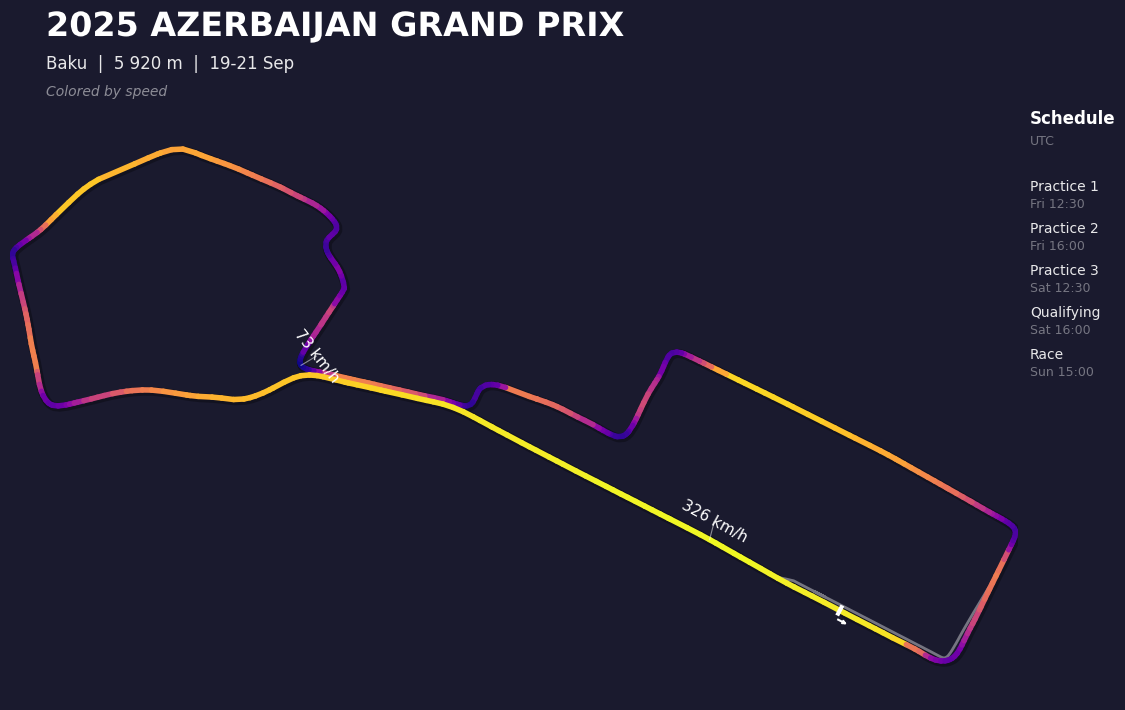

In [3]:
#manager.load_weekend(2025, 17, force_update=False)
print(manager.weekend.circuit)
manager.weekend.plot(color_mode="speed", track_width=4)

In [6]:
manager.weekend.race.lights_out_offset

3447.534

In [2]:
manager.weekend.race.warm_up_offset

3448.39

In [4]:
import pandas as pd
pd.set_option('display.max_rows', 10)
manager.load_weekend(2025, 17, sessions=["race"], force_update=True)
print(manager.weekend.race.telemetry["VER"])
print(manager.weekend.race.telemetry["RUS"])
print(manager.weekend.race.telemetry["PIA"])


📡 Building weekend data from FastF1...
→ Loading weekend 2025 Round 17...
  → Building circuit data...
  ✓ Rotation: 310° (manual override)
  ✓ Weekend complete: Azerbaijan Grand Prix
✓ Cached weekend to race_data/2025/17_Baku/Weekend.pkl

  → Race winner: VER
  → Extracting track from VER's telemetry...
  → Extracting track/pit from VER
    ✓ Track from lap 45 (102.9s): 384 points, 5920m
    ✓ Session timing: WarmUp starts at 3448.4s, Race starts at 3447.7s
    ✓ Marshal sectors: 21
  ✓ Updated weekend with track geometry (5920m, 21 sectors)

📡 Building session data from FastF1...
→ Loading session 2025 R17 R...
  → DNF drivers from results: PIA
  → Building telemetry from pos_data + car_data...
  → Race length: 51 laps
    ✓ VER: 34978 points
    ✓ RUS: 34978 points
    ✓ SAI: 34978 points
    ✓ ANT: 34978 points
    ✓ LAW: 34981 points
    ✓ TSU: 34978 points
    ✓ NOR: 34978 points
    ✓ HAM: 34978 points
    ✓ LEC: 34978 points
    ✓ HAD: 34978 points
    ✓ BOR: 34978 points
    

In [3]:
import pandas as pd
pd.set_option('display.max_rows', 5000)
manager.weekend.race.telemetry['LEC'].to_pandas().iloc[12600:14000]

,session_time,status,x,y,z,rpm,speed,n_gear,throttle,brake,drs,lap_number,compound,tyre_life,race_status,track_distance,race_distance,position,interval
12600,3366.133,OnTrack,454.0,3885.0,1986.0,3484.0,0.0,1,0.0,True,1,0,MEDIUM,1.0,WarmUp,330.046082,330.046082,4,2320.744000
12601,3366.413,OnTrack,454.0,3885.0,1986.0,3501.0,0.0,1,0.0,True,1,0,MEDIUM,1.0,WarmUp,330.046082,330.046082,4,2321.024000
12602,3366.633,OnTrack,454.0,3885.0,1986.0,3501.0,0.0,1,0.0,True,1,0,MEDIUM,1.0,WarmUp,330.046082,330.046082,4,2321.244000
12603,3366.814,OnTrack,454.0,3885.0,1986.0,3549.0,0.0,1,0.0,True,1,0,MEDIUM,1.0,WarmUp,330.046082,330.046082,4,2321.425000
12604,3367.134,OnTrack,454.0,3885.0,1986.0,3549.0,0.0,1,0.0,True,1,0,MEDIUM,1.0,WarmUp,330.046082,330.046082,4,2321.745000
12605,3367.393,OnTrack,454.0,3885.0,1986.0,3676.0,0.0,1,0.0,True,1,0,MEDIUM,1.0,WarmUp,330.046082,330.046082,4,2322.004000
12606,3367.532,OnTrack,454.0,3885.0,1986.0,3676.0,0.0,1,0.0,True,1,0,MEDIUM,1.0,WarmUp,330.046082,330.046082,4,2322.143000
12607,3367.812,OnTrack,454.0,3885.0,1986.0,3676.0,0.0,1,0.0,True,1,0,MEDIUM,1.0,WarmUp,330.046082,330.046082,4,2322.423000
12608,3368.153,OnTrack,454.0,3885.0,1986.0,3576.0,0.0,1,0.0,True,1,0,MEDIUM,1.0,WarmUp,330.046082,330.046082,4,2322.764000
12609,3368.413,OnTrack,454.0,3885.0,1986.0,3441.0,0.0,1,0.0,True,1,0,MEDIUM,1.0,WarmUp,330.046082,330.046082,4,2323.024000


In [4]:
import pandas as pd
pd.set_option('display.max_rows', 5000)
manager.weekend.race.get_telemetry_every_minute("LEC", interval=0.5).to_pandas()

,session_time,status,x,y,z,rpm,speed,n_gear,throttle,brake,drs,lap_number,compound,tyre_life,position,interval
0,1.468,OnTrack,0.0,0.0,0.0,0.0,0.0,0,104.0,True,3,0,SOFT,4.0,1,0.0
1,31.409,OnTrack,0.0,0.0,0.0,0.0,0.0,0,104.0,True,3,0,SOFT,4.0,1,0.0
2,61.469,OnTrack,0.0,0.0,0.0,0.0,0.0,0,104.0,True,3,0,SOFT,4.0,1,0.0
3,91.429,OnTrack,0.0,0.0,0.0,0.0,0.0,0,104.0,True,3,0,SOFT,4.0,1,0.0
4,121.409,OnTrack,0.0,0.0,0.0,0.0,0.0,0,104.0,True,3,0,SOFT,4.0,1,0.0
5,151.469,OnTrack,0.0,0.0,0.0,4117.0,0.0,0,0.0,False,1,0,SOFT,4.0,1,0.0
6,181.509,OnTrack,0.0,0.0,0.0,4043.0,0.0,0,0.0,False,1,0,SOFT,4.0,1,0.0
7,211.368,OnTrack,0.0,0.0,0.0,4014.0,0.0,0,0.0,False,8,0,SOFT,4.0,1,0.0
8,241.269,OnTrack,0.0,0.0,0.0,3887.0,0.0,0,0.0,False,8,0,SOFT,4.0,1,0.0
9,271.348,OnTrack,0.0,0.0,0.0,4055.0,0.0,0,0.0,False,8,0,SOFT,4.0,1,0.0


In [5]:
import pandas as pd
pd.set_option('display.max_rows', 5000)
manager.weekend.race.telemetry['LEC'].to_pandas().iloc[12600:14000]

,session_time,status,x,y,z,rpm,speed,n_gear,throttle,brake,drs,lap_number,compound,tyre_life,track_distance,race_distance,race_status,position,interval
12600,3399.669,OnTrack,-993.0,-1411.0,-241.0,8777.0,54.0,1,100.0,False,1,-1,MEDIUM,4.0,5714.439453,5714.439453,PreSession,4,0.0
12601,3399.869,OnTrack,-961.0,-1399.0,-242.0,11297.0,65.0,1,100.0,False,1,-1,MEDIUM,4.0,5717.856934,5717.856934,PreSession,4,0.0
12602,3400.049,OnTrack,-930.0,-1387.0,-242.0,12416.0,71.0,1,100.0,False,1,-1,MEDIUM,4.0,5721.181152,5721.181152,PreSession,4,0.0
12603,3400.309,OnTrack,-855.0,-1359.0,-242.0,12565.0,77.0,1,100.0,False,1,-1,MEDIUM,4.0,5729.187012,5729.187012,PreSession,4,0.0
12604,3400.589,OnTrack,-821.0,-1346.0,-242.0,10538.0,80.0,1,0.0,True,1,-1,MEDIUM,4.0,5732.826660,5732.826660,PreSession,4,0.0
12605,3400.890,OnTrack,-759.0,-1323.0,-242.0,10538.0,80.0,1,0.0,True,1,-1,MEDIUM,4.0,5739.439941,5739.439941,PreSession,4,0.0
12606,3401.070,OnTrack,-724.0,-1310.0,-242.0,7798.0,71.0,1,0.0,True,1,-1,MEDIUM,4.0,5743.173340,5743.173340,PreSession,4,0.0
12607,3401.310,OnTrack,-682.0,-1294.0,-243.0,7135.0,62.0,1,0.0,True,1,0,MEDIUM,4.0,5747.667480,5747.667480,WarmUp,4,0.0
12608,3401.590,OnTrack,-616.0,-1269.0,-243.0,6413.0,57.0,1,0.0,True,1,0,MEDIUM,4.0,5754.725098,5754.725098,WarmUp,4,0.0
12609,3401.990,OnTrack,-579.0,-1255.0,-243.0,5916.0,54.0,1,0.0,True,1,0,MEDIUM,4.0,5758.681152,5758.681152,WarmUp,4,0.0


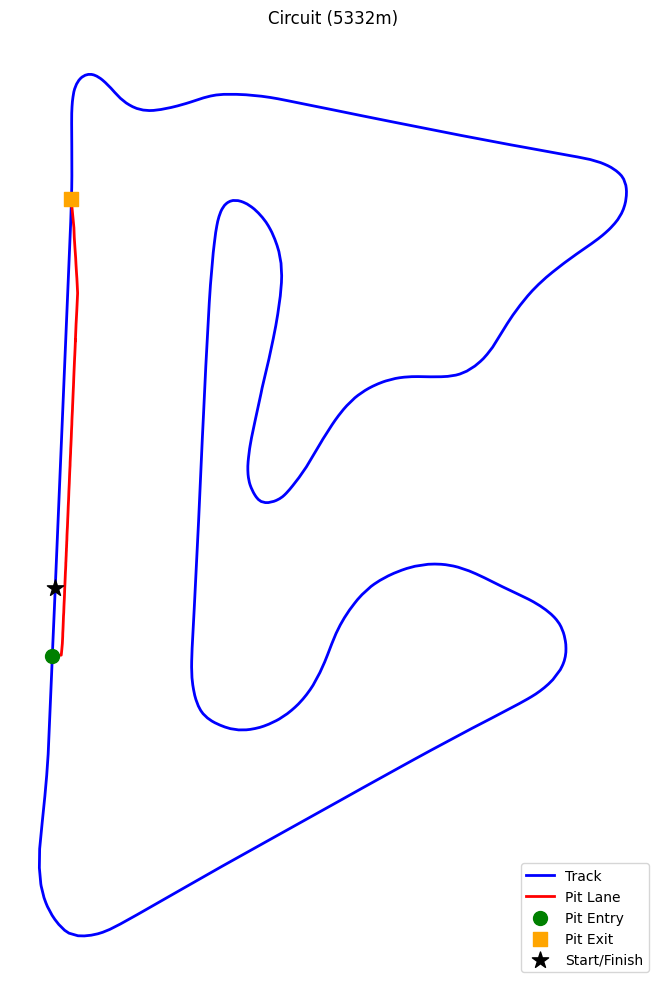

In [4]:
import matplotlib.pyplot as plt

def plot_circuit(circuit):
    """Plot circuit track and pit lane using matplotlib."""
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Plot main track
    track_x, track_y = circuit.track.get_full_track()
    ax.plot(track_x, track_y, 'b-', linewidth=2, label='Track')
    
    # Close the loop
    ax.plot([track_x[-1], track_x[0]], [track_y[-1], track_y[0]], 'b-', linewidth=2)
    
    # Plot pit lane if available
    if circuit.pit_lane:
        ax.plot(circuit.pit_lane.x, circuit.pit_lane.y, 'r-', linewidth=2, label='Pit Lane')
        # Mark entry/exit
        ax.scatter([circuit.pit_lane.x[0]], [circuit.pit_lane.y[0]], c='green', s=100, marker='o', label='Pit Entry', zorder=5)
        ax.scatter([circuit.pit_lane.x[-1]], [circuit.pit_lane.y[-1]], c='orange', s=100, marker='s', label='Pit Exit', zorder=5)
    
    # Mark start/finish
    ax.scatter([track_x[0]], [track_y[0]], c='black', s=150, marker='*', label='Start/Finish', zorder=5)
    
    ax.set_aspect('equal')
    ax.legend()
    ax.set_title(f'Circuit ({circuit.circuit_length:.0f}m)')
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()
# Usage:
plot_circuit(manager.weekend.circuit)

In [5]:
manager.weekend.circuit.distance_to_track([-82.0], [4646.0])

array([133.45853], dtype=float32)

First pit stop: 24.3s on lap 14
Window: 533 points (87 in pit)
Max distance to track: 13.65m
Entry point dist: 13.04m, Exit point dist: 13.31m


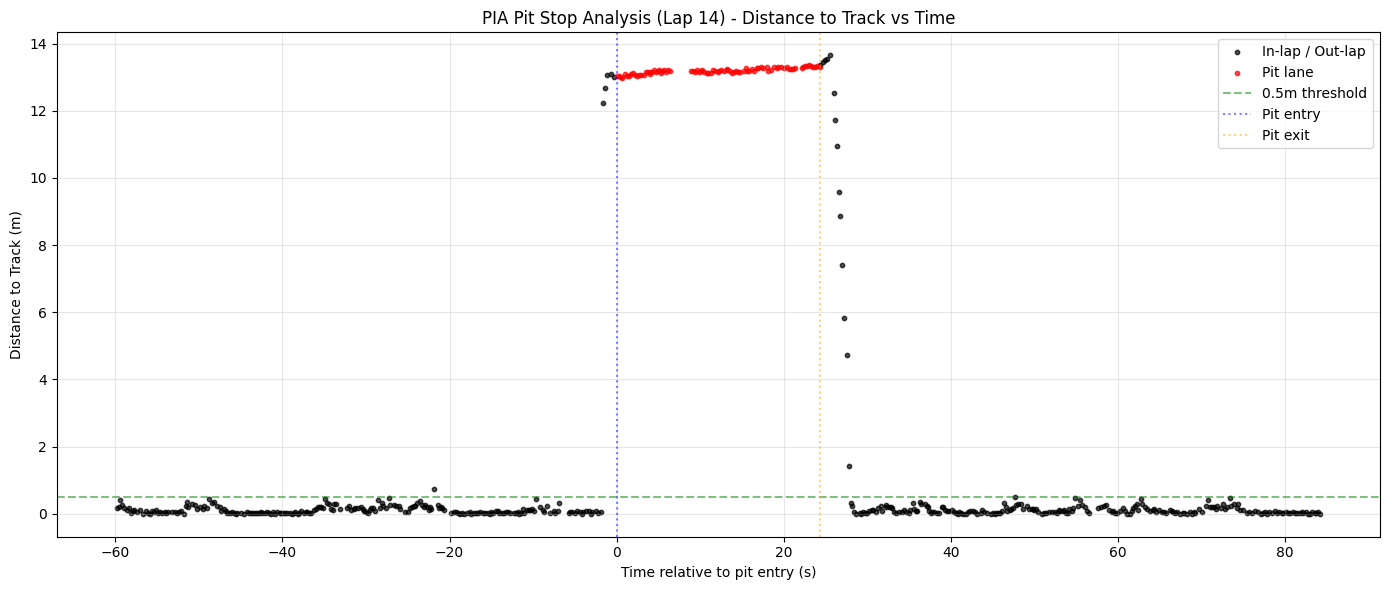

In [6]:
import numpy as np
import polars as pl

def plot_pit_analysis(session, driver, circuit):
    """Plot distance-to-track vs time for pit stop analysis."""
    tel = session.telemetry[driver]
    track_length = circuit.track.lap_distance
    
    # Find ALL pit rows sorted by time
    pit_rows = tel.filter(pl.col('race_status') == 'Pit').sort('session_time')
    if len(pit_rows) == 0:
        print(f"No pit stop found for {driver}")
        return
    
    # Find gaps > 60s to identify separate pit stops
    pit_times = pit_rows['session_time'].to_numpy()
    time_gaps = np.diff(pit_times)
    gap_indices = np.where(time_gaps > 60)[0]
    
    # Get FIRST pit stop only
    first_pit_end_idx = gap_indices[0] + 1 if len(gap_indices) > 0 else len(pit_rows)
    first_pit = pit_rows.head(first_pit_end_idx)
    pit_start_time = float(first_pit['session_time'][0])
    pit_end_time = float(first_pit['session_time'][-1])
    pit_lap = int(first_pit['lap_number'][0])
    
    print(f"First pit stop: {pit_end_time - pit_start_time:.1f}s on lap {pit_lap}")
    
    # Use 60s window around first pit stop
    expand_time = 60.0
    window = tel.filter(
        (pl.col('session_time') >= pit_start_time - expand_time) &
        (pl.col('session_time') <= pit_end_time + expand_time)
    ).sort('session_time')
    
    # Get data
    x = window['x'].to_numpy().astype(np.float32)
    y = window['y'].to_numpy().astype(np.float32)
    session_times = window['session_time'].to_numpy()
    
    # Use relative time (0 = pit entry)
    rel_time = session_times - pit_start_time
    
    # Distance to track (convert from decimeters to meters)
    dist_to_track = circuit.distance_to_track(x, y) / 10.0
    
    # Identify pit lane section
    is_pit = (window['race_status'] == 'Pit').to_numpy()
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plot non-pit (in-lap/out-lap) in black
    ax.scatter(rel_time[~is_pit], dist_to_track[~is_pit], c='black', s=10, label='In-lap / Out-lap', alpha=0.7)
    
    # Plot pit lane in red
    ax.scatter(rel_time[is_pit], dist_to_track[is_pit], c='red', s=10, label='Pit lane', alpha=0.7)
    
    # Add threshold line
    ax.axhline(y=0.5, color='green', linestyle='--', alpha=0.5, label='0.5m threshold')
    
    # Mark pit entry/exit times
    ax.axvline(x=0, color='blue', linestyle=':', alpha=0.5, label='Pit entry')
    ax.axvline(x=pit_end_time - pit_start_time, color='orange', linestyle=':', alpha=0.5, label='Pit exit')
    
    ax.set_xlabel('Time relative to pit entry (s)')
    ax.set_ylabel('Distance to Track (m)')
    ax.set_title(f'{driver} Pit Stop Analysis (Lap {pit_lap}) - Distance to Track vs Time')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    print(f"Window: {len(session_times)} points ({sum(is_pit)} in pit)")
    print(f"Max distance to track: {dist_to_track.max():.2f}m")
    print(f"Entry point dist: {dist_to_track[is_pit][0]:.2f}m, Exit point dist: {dist_to_track[is_pit][-1]:.2f}m")
    
    plt.tight_layout()
    plt.show()

# Run analysis for PIA
plot_pit_analysis(manager.session, 'PIA', manager.weekend.circuit)